In [25]:
import os, json, pickle, warnings, datetime as dt
import numpy as np, pandas as pd, yfinance as yf, torch
from ts2vec import TS2Vec
from sklearn.cluster import KMeans
import plotly.graph_objects as go
from tqdm import tqdm
warnings.filterwarnings("ignore")
from pathlib import Path  
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


In [ ]:
print(torch.__version__)
print(torch.cuda.is_available())

 Config – edit here only

In [31]:
TICKERS   = ["AAPL","MSFT","GOOG","AMZN","TSLA",
             "NVDA","META","JPM","V","BRK-B"]  # 10 for speed
TRAIN_BEG = "2000-01-01"
TRAIN_END = "2020-12-31"
TEST_BEG  = "2021-01-01"
TEST_END  = "2024-12-31"

LOOKBACK  = 64      # window length (bars)
STRIDE    = 1       # step size
EMB_DIM   = 320      # TS2Vec output size
N_EPOCHS  = 20      # keep small for today
N_CLUST   = 8       # K-Means clusters
CACHE_DIR = "data_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

2️⃣ Download & cache daily OHLCV

In [27]:
def get_ticker_df(tkr, cache_dir="data_cache", start="2010-01-01"):
    f = Path(cache_dir) / f"{tkr}.csv"
    if f.exists():
        return pd.read_csv(f, index_col=0, parse_dates=True)
    df = yf.download(tkr, start=start, progress=False)
    df.to_csv(f)
    return df


# Then build dfs:
dfs = {t: get_ticker_df(t) for t in tqdm(TICKERS)}
print("Downloaded:", len(dfs), "tickers")












100%|██████████| 10/10 [00:03<00:00,  2.61it/s]

Downloaded: 10 tickers


3️⃣ Train/Test split without leakage

In [28]:
from datetime import timedelta

def split_df(df, train_beg, train_end, test_beg, test_end, lookback):
    """Return (train_df, test_df) with a safety gap = lookback-1 bars."""
    # Raw calendar cuts
    train = df.loc[train_beg:train_end].copy()
    test  = df.loc[test_beg:test_end].copy()

    # Drop the last `lookback-1` rows of the train set so that
    # a window of length `lookback` cannot cross into the test period.
    cutoff = pd.to_datetime(train_end) - timedelta(days=lookback - 1)
    train  = train.loc[:cutoff]

    return train, test

train_dfs, test_dfs = {}, {}
for tkr, df in dfs.items():
    tr, te = split_df(df,
                      TRAIN_BEG, TRAIN_END,
                      TEST_BEG , TEST_END,
                      LOOKBACK)
    if len(tr) >= LOOKBACK and len(te) >= LOOKBACK:
        train_dfs[tkr] = tr
        test_dfs[tkr]  = te

print(f"✅  Train rows: {sum(len(x) for x in train_dfs.values()):,}"
      f"  |  Test rows: {sum(len(x) for x in test_dfs.values()):,}"
      f"  across {len(train_dfs)} tickers")

✅  Train rows: 26,539  |  Test rows: 10,050  across 10 tickers


# --- 4️⃣ Build sliding windows -----------------------------------------------

In [29]:

import numpy as np

def make_windows(arr, length, stride):
    """
    Return an array of shape [n_windows, length], guaranteed 2D,
    even if `arr` was accidentally 2D.
    """
    flat = arr.ravel()  # ensure 1-D view
    n = (len(flat) - length) // stride + 1
    return np.stack([flat[i*stride : i*stride + length]
                     for i in range(n)], axis=0)

def windows_from_dict(dfs_dict, length, stride):
    all_wins, meta = [], []
    for ticker, df in dfs_dict.items():
        closes = df["Close"].values.astype("float32")
        wins   = make_windows(closes, length, stride)
        all_wins.append(wins)
        meta.extend([(ticker, i) for i in range(wins.shape[0])])
    return np.vstack(all_wins), meta

train_X, train_meta = windows_from_dict(train_dfs, LOOKBACK, STRIDE)
test_X , test_meta  = windows_from_dict(test_dfs , LOOKBACK, STRIDE)

print(f"Train windows: {train_X.shape}  |  Test windows: {test_X.shape}")

Train windows: (25909, 64)  |  Test windows: (9420, 64)


# --- 5️⃣ Train mini-TS2Vec ----------------------------------------------------

In [32]:

# --- 5️⃣ Train mini-TS2Vec (fixed input type) -----------------------------
# Prepare train windows as a numpy array [N_windows, length, 1]

print(DEVICE)
train_data = train_X[:, :, None]  # shape (N, LOOKBACK, 1)

# Instantiate the model
model = TS2Vec(input_dims=1, output_dims=EMB_DIM, device=DEVICE)

# Train for N_EPOCHS epochs (you'll see a tqdm progress bar)
model.fit(train_data, n_epochs=N_EPOCHS, verbose=True)

cuda
Epoch #0: loss=146.2204771546982
Epoch #1: loss=3.940334935332611
Epoch #2: loss=3.3302771900081574
Epoch #3: loss=3.452574481781505
Epoch #4: loss=1.8380789972146843
Epoch #5: loss=1.9193035773909923
Epoch #6: loss=1.4636204675290967
Epoch #7: loss=1.3824119259723548
Epoch #8: loss=1.379867590232128
Epoch #9: loss=1.242416925346358
Epoch #10: loss=1.1949150733847616
Epoch #11: loss=1.1797285568316531
Epoch #12: loss=1.11054245456639
Epoch #13: loss=1.030534707189269
Epoch #14: loss=0.9910623318181501
Epoch #15: loss=0.9347687089899722
Epoch #16: loss=0.896608708797965
Epoch #17: loss=0.8687321177193086
Epoch #18: loss=0.8235583487044447
Epoch #19: loss=0.7932376033770884


[146.2204771546982,
 3.940334935332611,
 3.3302771900081574,
 3.452574481781505,
 1.8380789972146843,
 1.9193035773909923,
 1.4636204675290967,
 1.3824119259723548,
 1.379867590232128,
 1.242416925346358,
 1.1949150733847616,
 1.1797285568316531,
 1.11054245456639,
 1.030534707189269,
 0.9910623318181501,
 0.9347687089899722,
 0.896608708797965,
 0.8687321177193086,
 0.8235583487044447,
 0.7932376033770884]

# --- 6️⃣ Embed & Cluster -----------------------------------------------------

In [33]:
import numpy as np
import torch
from sklearn.cluster import KMeans

# 1) Prepare test windows as float32 NumPy [N, LOOKBACK, 1]
test_np = np.asarray(test_X[:, :, None], dtype=np.float32)

# 2) Encode via TS2Vec (may return 3D)
emb = model.encode(test_np)

# 3) If it's a torch tensor, convert to NumPy
if hasattr(emb, "detach"):
    emb = emb.detach().cpu().numpy()

# 4) emb now is either shape (N, LOOKBACK, EMB_DIM) or (N, EMB_DIM)
if emb.ndim == 3:
    # Option A: take the last time-step as the window embedding
    emb_2d = emb[:, -1, :]
    # —or— Option B: average across time:
    # emb_2d = emb.mean(axis=1)
else:
    emb_2d = emb

# 5) Cluster the 2D embeddings
kmeans = KMeans(n_clusters=N_CLUST, random_state=42)
labels = kmeans.fit_predict(emb_2d)

# 6) Sanity-check counts
unique, counts = np.unique(labels, return_counts=True)
print("Cluster counts:", dict(zip(unique, counts)))

Cluster counts: {np.int32(0): np.int64(1799), np.int32(1): np.int64(1173), np.int32(2): np.int64(566), np.int32(3): np.int64(999), np.int32(4): np.int64(750), np.int32(5): np.int64(174), np.int32(6): np.int64(2453), np.int32(7): np.int64(1506)}


# --- 7️⃣ Quick-Look Plot: cluster markers on price chart --------------------

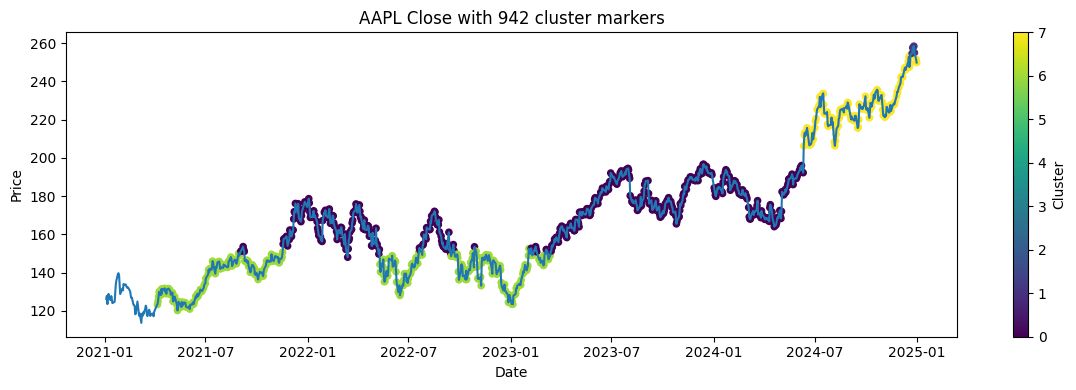

In [34]:
import plotly.graph_objects as go
import matplotlib.pyplot as plt

def plot_ticker_clusters_mpl(tkr):
    df = test_dfs[tkr]
    # compute window‐end points exactly as before
    win_idxs = [i for i,(tk,_) in enumerate(test_meta) if tk==tkr]
    ends     = [test_meta[i][1] + LOOKBACK - 1 for i in win_idxs]
    times    = df.index[ends]
    prices   = df["Close"].iloc[ends]
    colors   = [int(labels[i]) for i in win_idxs]

    plt.figure(figsize=(12,4))
    plt.plot(df.index, df["Close"], label=tkr)
    sc = plt.scatter(times, prices, c=colors, cmap="viridis", s=20)
    plt.colorbar(sc, label="Cluster")
    plt.title(f"{tkr} Close with {len(times)} cluster markers")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.tight_layout()
    plt.show()

plot_ticker_clusters_mpl("AAPL")






AAPL: 942 markers — cluster counts Counter({0: 486, 6: 315, 7: 137, 1: 4})


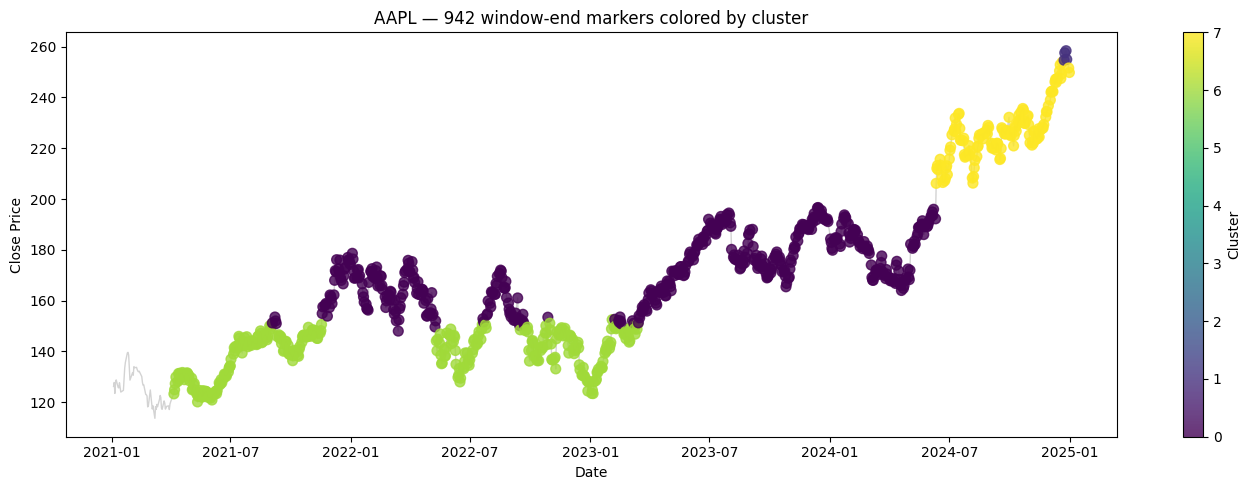

MSFT: 942 markers — cluster counts Counter({1: 289, 2: 244, 3: 219, 7: 190})


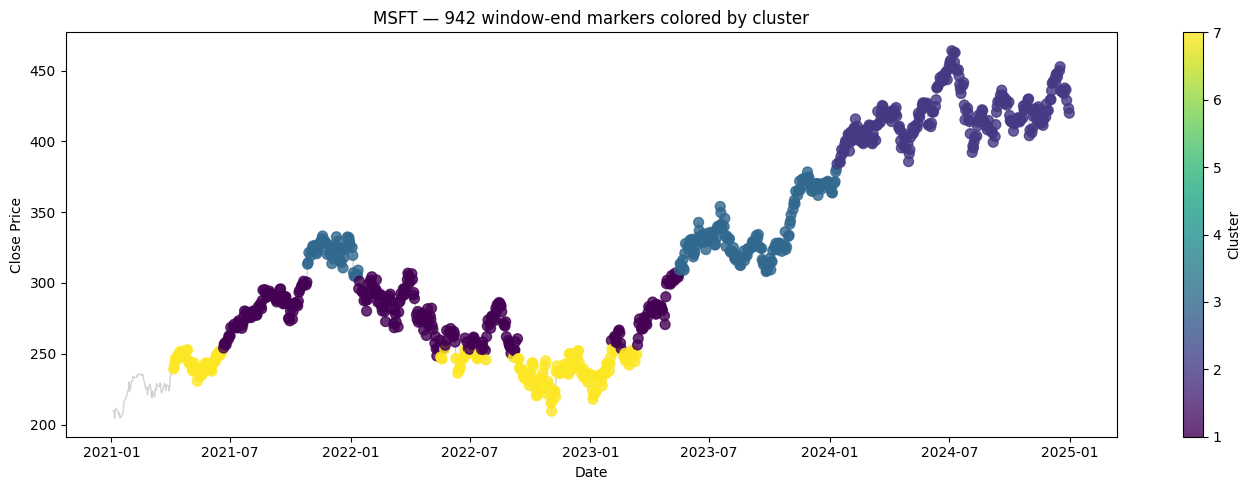

GOOG: 942 markers — cluster counts Counter({6: 745, 0: 196, 4: 1})


  0%|          | 0/10 [21:22<?, ?it/s]


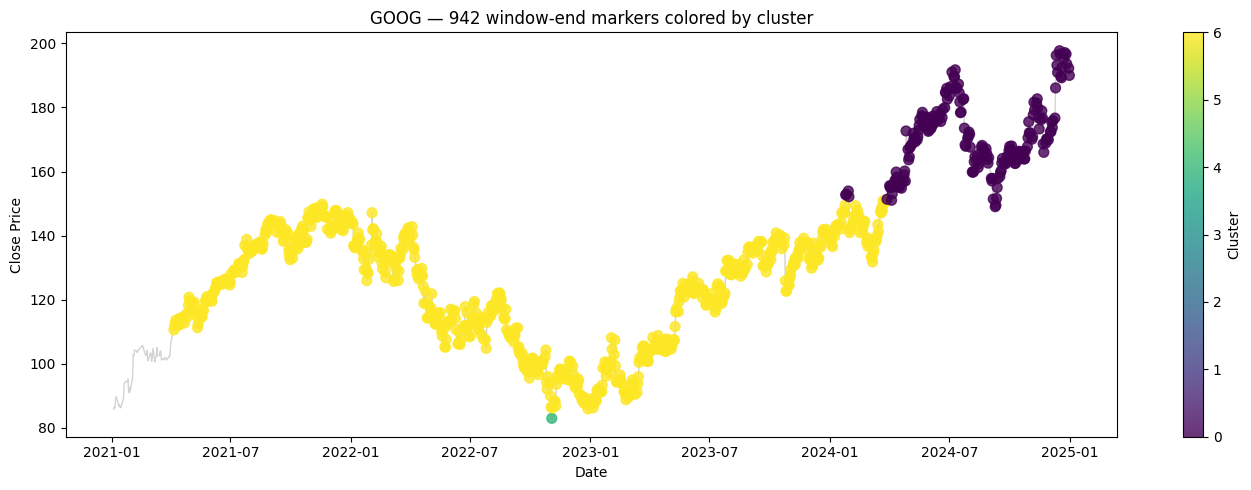

AMZN: 942 markers — cluster counts Counter({0: 465, 6: 434, 7: 36, 4: 7})


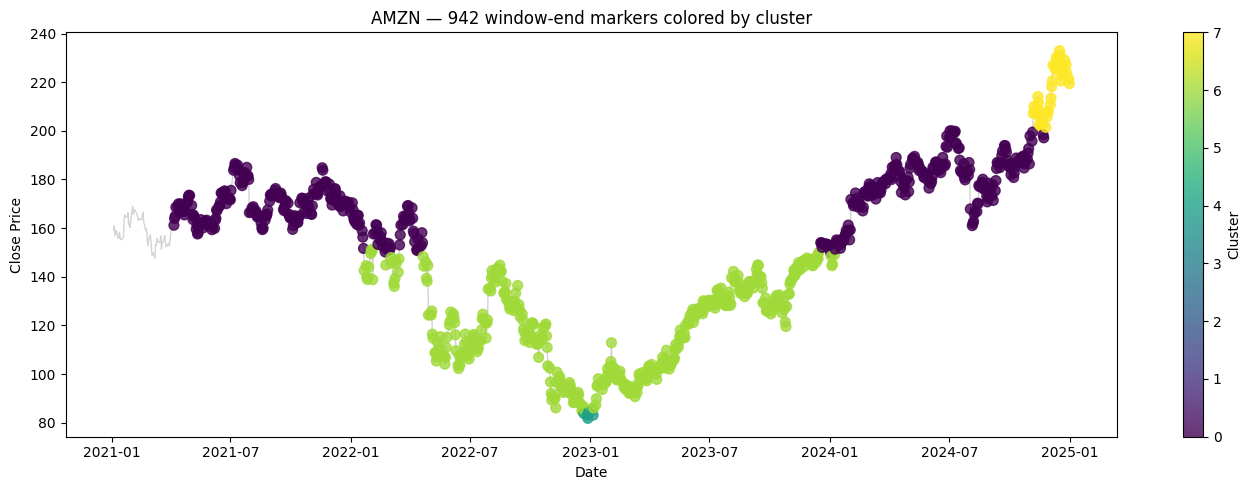

TSLA: 942 markers — cluster counts Counter({7: 365, 0: 221, 1: 201, 3: 105, 6: 26, 2: 24})


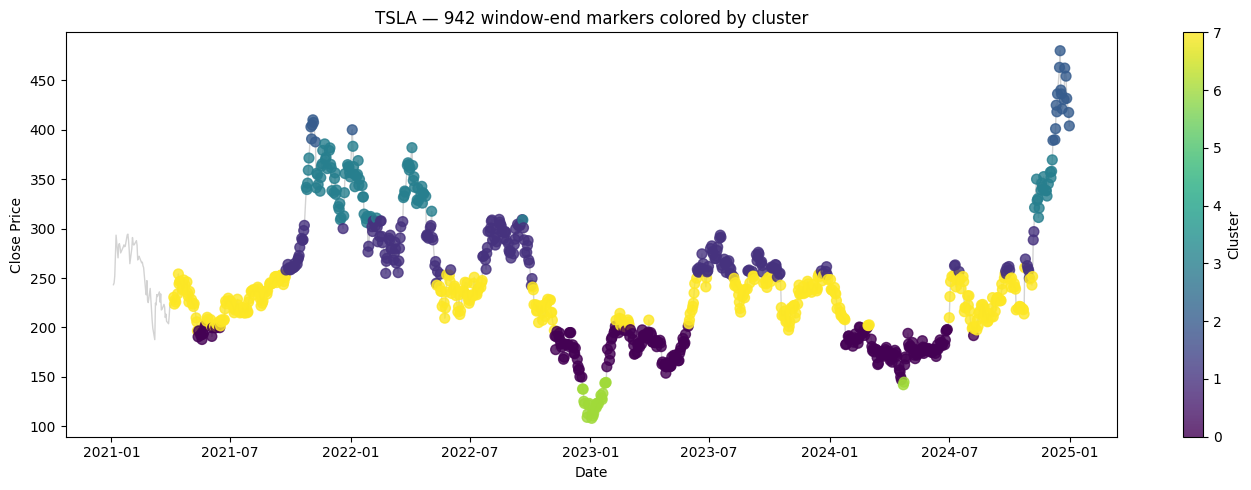

NVDA: 942 markers — cluster counts Counter({4: 742, 6: 200})


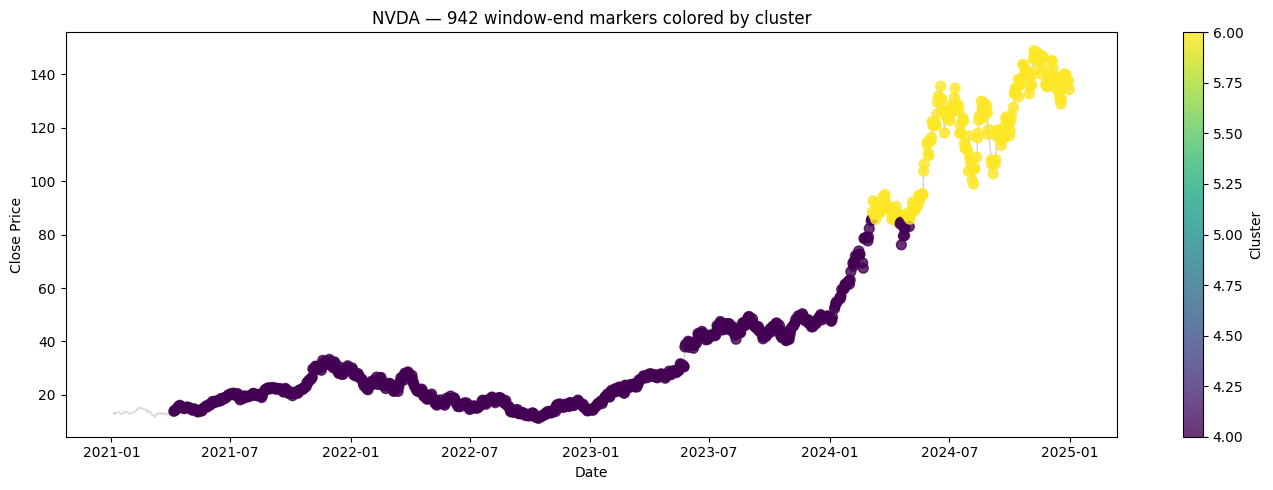

META: 942 markers — cluster counts Counter({3: 273, 5: 174, 0: 141, 1: 104, 6: 94, 7: 93, 2: 63})


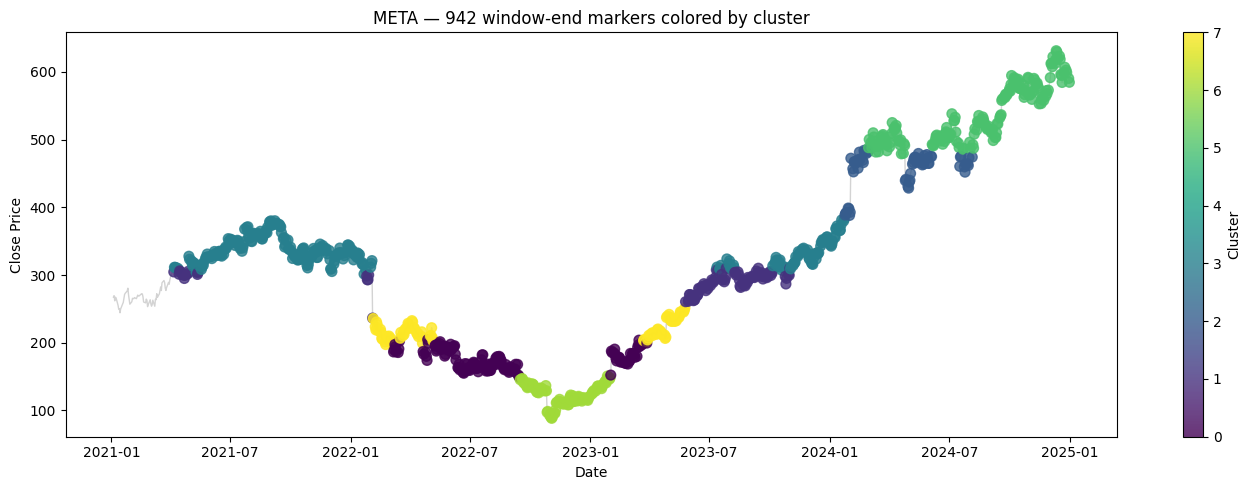

JPM: 942 markers — cluster counts Counter({6: 639, 0: 182, 7: 121})


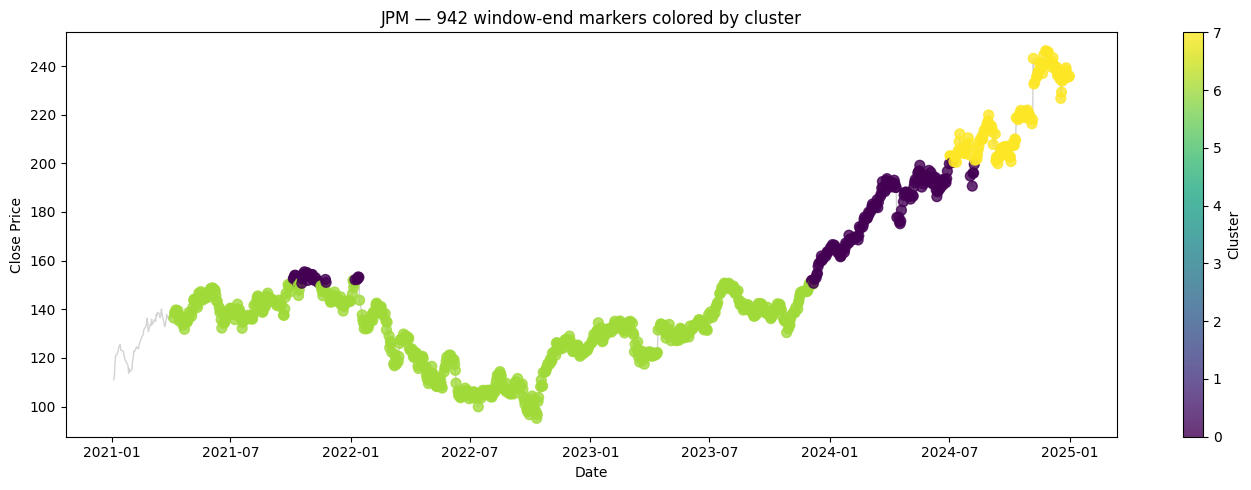

V: 942 markers — cluster counts Counter({7: 564, 1: 238, 0: 108, 3: 32})


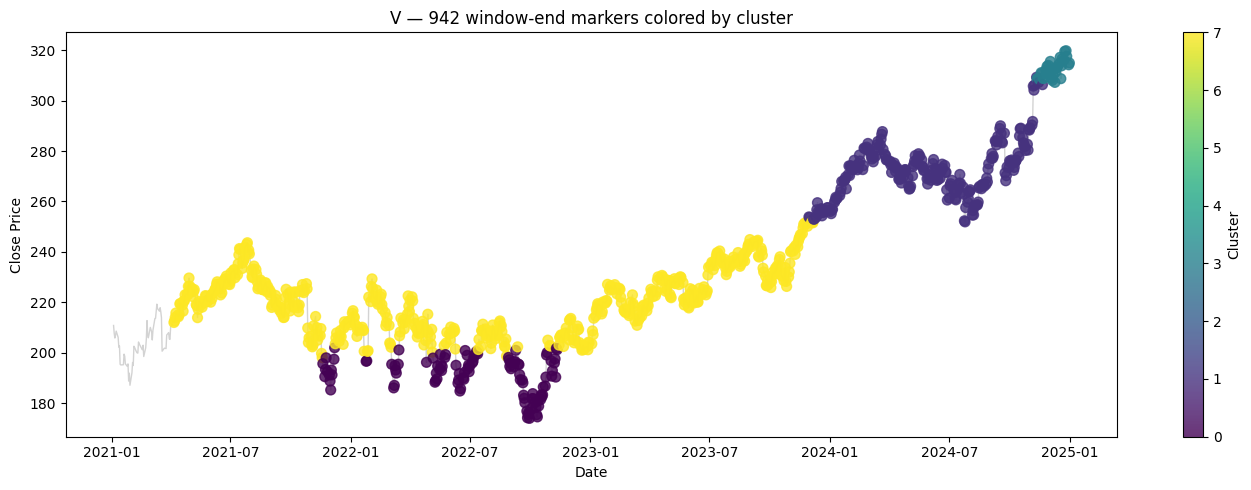

BRK-B: 942 markers — cluster counts Counter({3: 370, 1: 337, 2: 235})


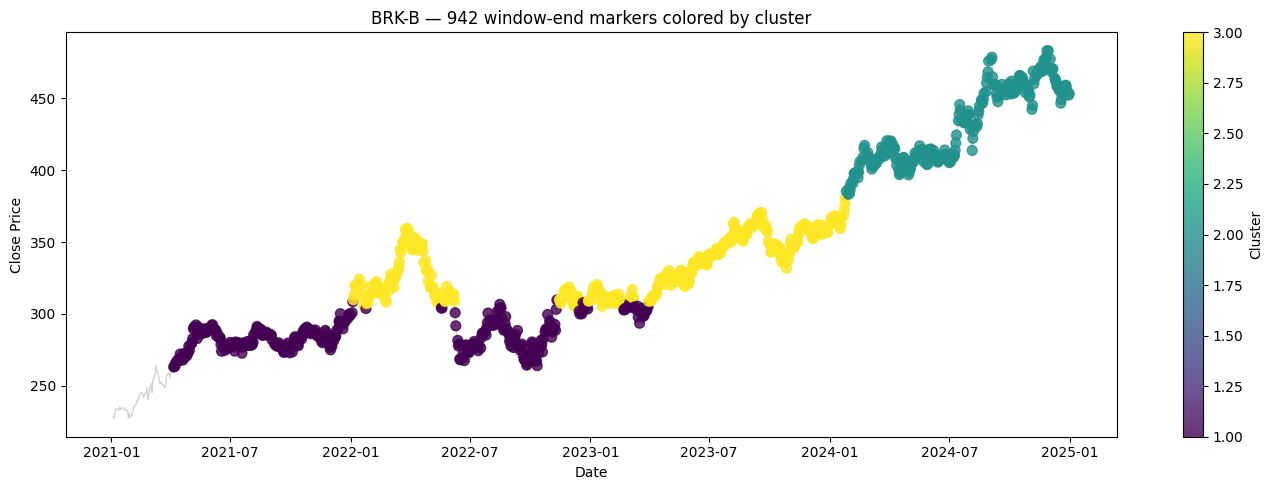

In [35]:
import matplotlib.pyplot as plt
from collections import Counter

def plot_clusters_price_mpl(tkr):
    df = test_dfs[tkr]                      # Close series
    win = [i for i,(tk,_) in enumerate(test_meta) if tk == tkr]
    ends = [test_meta[i][1] + LOOKBACK - 1 for i in win]

    times    = [df.index[e]         for e in ends]
    prices   = [df["Close"].iloc[e] for e in ends]
    clusters = [int(labels[i])       for i in win]

    print(f"{tkr}: {len(times)} markers — cluster counts {Counter(clusters)}")

    # --- PLOT ---------------------------------------------------------------
    plt.figure(figsize=(14,5))
    # 1️⃣ price line   (light gray, behind)
    plt.plot(df.index, df["Close"], linewidth=1, color="lightgray", zorder=1)

    # 2️⃣ scatter of window-ends (colored by cluster, on top)
    sc = plt.scatter(times, prices, c=clusters,
                     cmap="viridis", s=50, alpha=0.8, zorder=2)
    cbar = plt.colorbar(sc, label="Cluster")
    cbar.set_alpha(1)           # make colorbar opaque
    #cbar.draw_all()

    plt.title(f"{tkr} — {len(times)} window-end markers colored by cluster")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.tight_layout()
    plt.show()

for tkr in test_dfs.keys():
    plot_clusters_price_mpl(tkr)

In [ ]:
from bokeh.io import output_notebook, show
from bokeh.plotting import figure
from bokeh.models import ColumnDataSource, HoverTool, ColorBar, LinearColorMapper, FixedTicker
from bokeh.palettes import Viridis256
import numpy as np
from collections import Counter

output_notebook()

def plot_clusters_bokeh(tkr):
    df = test_dfs[tkr]
    win = [i for i,(tk,_) in enumerate(test_meta) if tk == tkr]
    ends = [test_meta[i][1] + LOOKBACK - 1 for i in win]

    times    = np.array([df.index[e]         for e in ends], dtype="datetime64[ns]")
    prices   = np.array([df["Close"].iloc[e] for e in ends])
    clusters = np.array([int(labels[i])       for i in win])

    print(f"{tkr}: {len(times)} markers — cluster counts {Counter(clusters)}")

    n_clust = clusters.max() + 1
    palette = Viridis256[:: max(1, 256 // n_clust)][:n_clust]
    mapper  = LinearColorMapper(palette=palette, low=0, high=n_clust-1)

    p = figure(height=450, width=900, x_axis_type="datetime",
               title=f"{tkr} – window-end cluster markers")
    p.line(df.index, df["Close"], line_width=1, color="#d3d3d3", legend_label=tkr)

    cds = ColumnDataSource(dict(x=times, y=prices, cluster=clusters))
    p.circle("x", "y", source=cds, size=7,
             fill_color={"field": "cluster", "transform": mapper},
             line_color=None, fill_alpha=0.8, legend_label="Windows")

    p.add_tools(HoverTool(tooltips=[
        ("Date"   , "@x{%F}"),
        ("Close"  , "@y{0.2f}"),
        ("Cluster", "@cluster"),
    ], formatters={"@x": "datetime"}))

    color_bar = ColorBar(color_mapper=mapper, title="Cluster",
                         location=(0, 0),
                         ticker=FixedTicker(ticks=list(range(n_clust))))
    p.add_layout(color_bar, "right")

    p.legend.location = "top_left"
    show(p)

# Example call
plot_clusters_bokeh("AAPL")

In [ ]:
import pandas as pd, altair as alt
alt.data_transformers.disable_max_rows()  # show > 5k points

def plot_clusters_altair(tkr):
    df      = test_dfs[tkr]
    win     = [i for i,(tk,_) in enumerate(test_meta) if tk == tkr]
    ends    = [test_meta[i][1] + LOOKBACK - 1 for i in win]
    plot_df = pd.DataFrame({
        "Date"   : df.index[ends],
        "Close"  : df["Close"].iloc[ends].to_numpy(),
        "Cluster": [int(labels[i]) for i in win],
    })

    base = alt.Chart(df.reset_index()).mark_line(color="#d3d3d3").encode(
        x="Date:T", y="Close:Q"
    )

    dots = alt.Chart(plot_df).mark_circle(size=50).encode(
        x="Date:T",
        y="Close:Q",
        color=alt.Color("Cluster:N", scale=alt.Scale(scheme="viridis")),
        tooltip=["Date:T","Close:Q","Cluster:N"]
    )

    alt.layer(base, dots).properties(width=900, height=400,
                                     title=f"{tkr} – window-end clusters").interactive()

plot_clusters_altair("AAPL")